# [M3S01] - Ex. 4 — Regressão Linear Simples

**Objetivo:** construir um modelo de regressão linear simples para prever a demanda de um medicamento com base no investimento em marketing.

- **Variável preditora (X):** `investimento_marketing`
- **Variável resposta (y):** `demanda`

**Base de dados:** `dados_AP - [M3S01] - Ex. 1 até [M3S03] - Ex. 4.csv`

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## 1. Carregamento e inspeção dos dados

In [17]:
df = pd.read_csv('../../data/input/csv/dados_AP - [M3S01] - Ex. 1 até [M3S03] - Ex. 4.csv')
print(df.shape)
df.head()

(20000, 4)


,investimento_marketing,preco_medicamento,mes,demanda
0,16795,844,11,353
1,1860,172,5,60
2,39158,331,12,55
3,45732,313,1,61
4,12284,617,2,269


In [18]:
df.describe()

,investimento_marketing,preco_medicamento,mes,demanda
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,25309.677500,510.190000,6.572000,193.924100
std,14084.898888,282.045802,3.432012,131.875668
min,1002.000000,20.000000,1.000000,0.000000
25%,13120.750000,268.000000,4.000000,71.000000
50%,25056.000000,511.000000,7.000000,185.000000
75%,37520.000000,752.000000,10.000000,306.000000
max,49998.000000,998.000000,12.000000,496.000000


## 2. Visualização da relação entre as variáveis

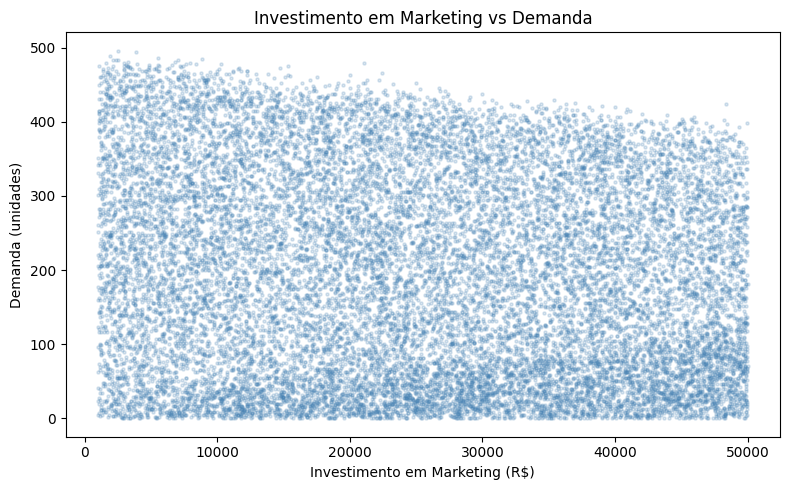

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df['investimento_marketing'], df['demanda'], color='steelblue', alpha=0.2, s=5)
plt.xlabel('Investimento em Marketing (R$)')
plt.ylabel('Demanda (unidades)')
plt.title('Investimento em Marketing vs Demanda')
plt.tight_layout()
plt.show()

## 3. Modelo de Regressão Linear Simples

In [20]:
X = df[['investimento_marketing']]
y = df['demanda']

modelo = LinearRegression()
modelo.fit(X, y)

coef = modelo.coef_[0]
intercepto = modelo.intercept_
r2 = r2_score(y, modelo.predict(X))
rmse = np.sqrt(mean_squared_error(y, modelo.predict(X)))

print(f'Coeficiente (β₁): {coef:.6f}')
print(f'Intercepto  (β₀): {intercepto:.4f}')
print(f'R²:               {r2:.4f}')
print(f'RMSE:             {rmse:.4f}')
print(f'\nEquação: demanda = {intercepto:.2f} + {coef:.6f} × investimento_marketing')

Coeficiente (β₁): -0.001489
Intercepto  (β₀): 231.6092
R²:               0.0253
RMSE:             130.1942

Equação: demanda = 231.61 + -0.001489 × investimento_marketing


## 4. Visualização da reta de regressão

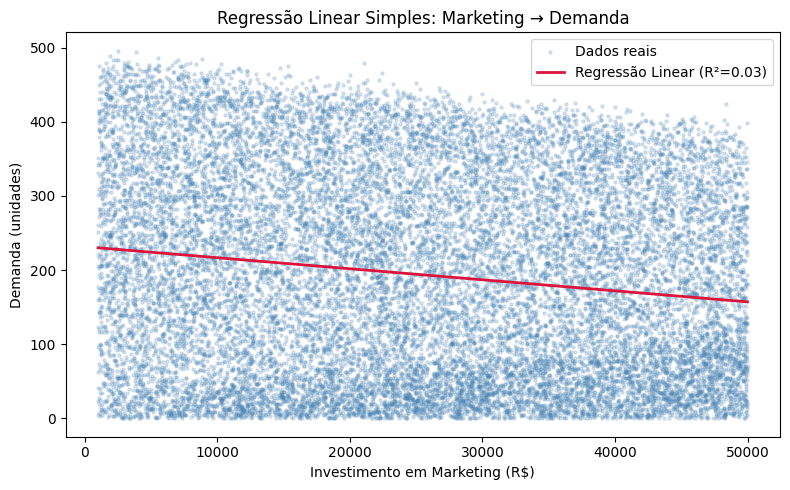

In [21]:
x_range = pd.DataFrame(
    {'investimento_marketing': np.linspace(df['investimento_marketing'].min(), df['investimento_marketing'].max(), 100)}
)
y_pred_line = modelo.predict(x_range)

plt.figure(figsize=(8, 5))
plt.scatter(df['investimento_marketing'], df['demanda'], color='steelblue', alpha=0.2, s=5, label='Dados reais')
plt.plot(x_range, y_pred_line, color='crimson', linewidth=2, label=f'Regressão Linear (R²={r2:.2f})')
plt.xlabel('Investimento em Marketing (R$)')
plt.ylabel('Demanda (unidades)')
plt.title('Regressão Linear Simples: Marketing → Demanda')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpretação dos resultados

### A relação é positiva ou negativa?

A relação é **negativa**: o coeficiente β₁ é menor que zero, indicando que, isoladamente, maiores investimentos em marketing estão associados a uma demanda ligeiramente menor. Porém, o **R² = 0.03** revela que o modelo explica apenas 3% da variação na demanda — ou seja, `investimento_marketing` sozinho **não é um bom preditor**.

### Isso faz sentido no contexto de negócio?

**Não diretamente.** Intuitivamente esperaríamos uma relação positiva. O resultado negativo e fraco pode indicar dois cenários comuns em contextos farmacêuticos:

- **Investimento reativo:** a empresa aumenta o marketing justamente quando a demanda está baixa, criando uma correlação inversa nos dados históricos.
- **Variável insuficiente:** outros fatores como `preco_medicamento` e `mes` têm peso maior na demanda. Para um modelo útil, todas as variáveis preditoras precisam ser incluídas juntas (regressão múltipla).